# Materials Clustering Analysis

This notebook groups the prepared materials dataset into technically similar families using unsupervised learning. The goal is not to prove direct one-to-one substitution, but to derive useful similarity structure that can support the later pricing stage, where lower-cost candidate materials will be compared within technically similar groups.

In [42]:
# Import the libraries used in this notebook section.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
# Group similar records and evaluate the quality of the cluster structure.
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [43]:
# Set up project paths so files can be read and outputs can be organised consistently.
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd

processed_dir = project_root / "data" / "processed"
results_dir = project_root / "results" / "materials_clustering"
supporting_results_dir = results_dir / "supporting"
results_dir.mkdir(parents=True, exist_ok=True)
supporting_results_dir.mkdir(parents=True, exist_ok=True)

reference_path = processed_dir / "materials_clustering_reference.csv"
features_path = processed_dir / "materials_clustering_features.csv"

# Group similar records and evaluate the quality of the cluster structure.
cluster_metrics_output = supporting_results_dir / "materials_cluster_model_comparison.csv"
cluster_assignments_output = results_dir / "materials_cluster_assignments.csv"
cluster_summary_output = supporting_results_dir / "materials_cluster_summary.csv"
cluster_representatives_output = supporting_results_dir / "materials_cluster_representatives.csv"
cluster_neighbors_output = results_dir / "materials_cluster_nearest_neighbors.csv"
cluster_feature_rank_output = results_dir / "materials_cluster_feature_rankings.csv"

print("Reference file:", reference_path)
print("Feature file:", features_path)
print("Results directory:", results_dir)
print("Supporting results directory:", supporting_results_dir)

Reference file: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\data\processed\materials_clustering_reference.csv
Feature file: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\data\processed\materials_clustering_features.csv
Results directory: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_clustering
Supporting results directory: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_clustering\supporting


In [44]:
# Check that the expected input files are available before continuing.
for path in [reference_path, features_path]:
    if not path.exists():
        # Handle missing values so later transformations and models do not fail.
        raise FileNotFoundError(f"Missing required clustering input file: {path}")

## Load clustering inputs

In [45]:
# Load the dataset needed for the next analysis step.
reference_df = pd.read_csv(reference_path)
features_df = pd.read_csv(features_path)

# Inspect the data to confirm the structure and values look reasonable.
print("Reference shape:", reference_df.shape)
display(reference_df.head())

print("Feature matrix shape:", features_df.shape)
display(features_df.head())

Reference shape: (33951, 10)


,material_id,formula_pretty,formula_match_key,elements,elements_list,material_family_key,material_family_match_key,is_stable,is_metal,symmetry
0,mp-862690,Ac,ac,['Ac'],['Ac'],Ac,ac,True,True,Hexagonal
1,mp-1183076,Ac2AgPb,ac2agpb,"['Ac', 'Ag', 'Pb']","['Ac', 'Ag', 'Pb']",Ac_Ag_Pb,ac_ag_pb,True,True,Cubic
2,mp-1183086,Ac2CdHg,ac2cdhg,"['Ac', 'Cd', 'Hg']","['Ac', 'Cd', 'Hg']",Ac_Cd_Hg,ac_cd_hg,True,True,Cubic
3,mp-862786,Ac2CuGe,ac2cuge,"['Ac', 'Cu', 'Ge']","['Ac', 'Cu', 'Ge']",Ac_Cu_Ge,ac_cu_ge,True,True,Cubic
4,mp-861883,Ac2CuIr,ac2cuir,"['Ac', 'Cu', 'Ir']","['Ac', 'Cu', 'Ir']",Ac_Cu_Ir,ac_cu_ir,True,True,Cubic


Feature matrix shape: (33951, 9)


,nelements,nsites,density,density_atomic,volume,band_gap,energy_per_atom,formation_energy_per_atom,is_metal_flag
0,1,4,8.170182,46.136350,184.545401,0.0,-68.637479,0.000000,1.0
1,3,4,9.490476,33.640774,134.563097,0.0,-54.209271,-0.480278,1.0
2,3,4,9.570977,33.268160,133.072641,0.0,-52.120621,-0.433682,1.0
3,3,4,8.598305,28.494770,113.979079,0.0,-40.884684,-0.386251,1.0
4,3,4,11.322190,26.023879,104.095515,0.0,-50.462576,-0.342299,1.0


## Scale features and prepare PCA view

In [46]:
# Choose the columns that will be used as features or summary variables.
feature_names = features_df.columns.tolist()
# Define the modelling target and input features.
X = features_df.to_numpy(dtype=float)

# Build preprocessing steps for numeric, categorical, and text inputs.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Inspect the data to confirm the structure and values look reasonable.
print("Feature columns used:", feature_names)
print("Explained variance by first two PCA components:", pca.explained_variance_ratio_)

Feature columns used: ['nelements', 'nsites', 'density', 'density_atomic', 'volume', 'band_gap', 'energy_per_atom', 'formation_energy_per_atom', 'is_metal_flag']
Explained variance by first two PCA components: [0.43021816 0.16955456]


## Run multiple clustering algorithms

This stage tests several clustering approaches so the final grouping is not chosen arbitrarily. We compare fixed-`k` and density-based methods, then keep the most interpretable solution for downstream material profiling.

In [47]:
# Filter the data to keep the records relevant for this step.
cluster_runs = []
# Group similar records and evaluate the quality of the cluster structure.
cluster_labels_by_model = {}
k_search_values = list(range(2, 9))
kmeans_inertia_rows = []

# Define the model or model set that will be trained and compared.
models = {}
for k in k_search_values:
    models[f"KMeans_k{k}"] = KMeans(n_clusters=k, random_state=42, n_init=10)
    models[f"Agglomerative_k{k}"] = AgglomerativeClustering(n_clusters=k)

models["DBSCAN_eps0.9_min5"] = DBSCAN(eps=0.9, min_samples=5)

for model_name, model in models.items():
    labels = model.fit_predict(X_scaled)
    cluster_labels_by_model[model_name] = labels

    if isinstance(model, KMeans):
        kmeans_inertia_rows.append({"k": model.n_clusters, "inertia": float(model.inertia_)})

    non_noise_mask = labels != -1
    unique_clusters = set(labels)
    n_clusters = len(unique_clusters - {-1})
    noise_points = int((labels == -1).sum())

    if n_clusters >= 2 and non_noise_mask.sum() >= 2:
        eval_X = X_scaled[non_noise_mask]
        eval_labels = labels[non_noise_mask]
        silhouette = silhouette_score(eval_X, eval_labels)
        davies_bouldin = davies_bouldin_score(eval_X, eval_labels)
        calinski_harabasz = calinski_harabasz_score(eval_X, eval_labels)
    else:
        silhouette = np.nan
        davies_bouldin = np.nan
        calinski_harabasz = np.nan

    cluster_runs.append({
        "model": model_name,
        "n_clusters": n_clusters,
        "noise_points": noise_points,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies_bouldin,
        "calinski_harabasz_score": calinski_harabasz,
    })

# Calculate evaluation metrics to judge model or pipeline performance.
cluster_metrics_df = pd.DataFrame(cluster_runs)
# Summarise the data so patterns can be compared more easily.
kmeans_inertia_df = pd.DataFrame(kmeans_inertia_rows).sort_values("k").reset_index(drop=True)
# Inspect the data to confirm the structure and values look reasonable.
display(cluster_metrics_df.sort_values(["silhouette_score", "calinski_harabasz_score"], ascending=[False, False]))

,model,n_clusters,noise_points,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,KMeans_k2,2,0,0.317251,1.309901,16382.248662
1,Agglomerative_k2,2,0,0.302931,1.345319,15125.443543
2,KMeans_k3,3,0,0.299510,1.521435,12241.679745
3,Agglomerative_k3,3,0,0.289216,1.707268,11192.649169
6,KMeans_k5,5,0,0.287434,1.263161,11312.210915
4,KMeans_k4,4,0,0.278937,1.340762,11232.913900
8,KMeans_k6,6,0,0.263101,1.363228,10263.521951
7,Agglomerative_k5,5,0,0.245713,1.396068,9626.958450
10,KMeans_k7,7,0,0.244666,1.429802,9376.318636
5,Agglomerative_k4,4,0,0.243211,1.594778,9871.097369


## Visual comparison of cluster quality

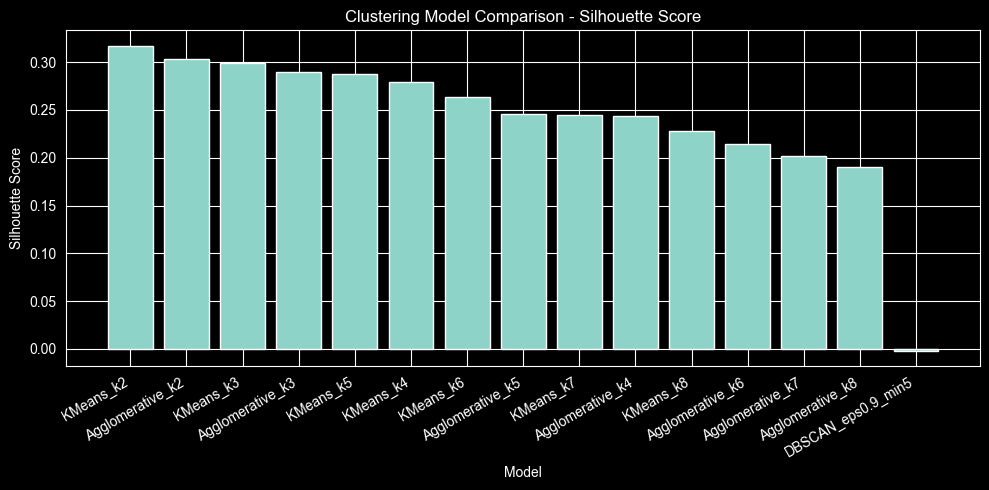

In [48]:
# Summarise the data so patterns can be compared more easily.
plot_df = cluster_metrics_df.sort_values("silhouette_score", ascending=False).reset_index(drop=True)

# Plot the result so the pattern is easier to interpret visually.
plt.figure(figsize=(10, 5))
# Group similar records and evaluate the quality of the cluster structure.
plt.bar(plot_df["model"], plot_df["silhouette_score"])
plt.title("Clustering Model Comparison - Silhouette Score")
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Choose the best cluster count for centroid and hierarchical models

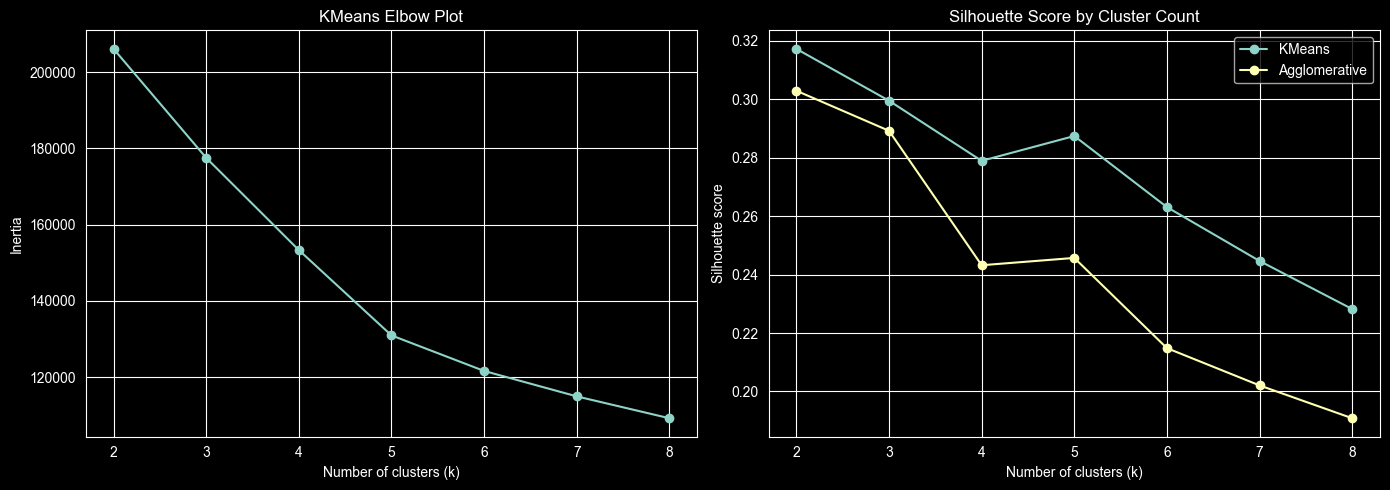

,model,n_clusters,noise_points,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,KMeans_k2,2,0,0.317251,1.309901,16382.248662
2,KMeans_k3,3,0,0.299510,1.521435,12241.679745
4,KMeans_k4,4,0,0.278937,1.340762,11232.913900
6,KMeans_k5,5,0,0.287434,1.263161,11312.210915
8,KMeans_k6,6,0,0.263101,1.363228,10263.521951
10,KMeans_k7,7,0,0.244666,1.429802,9376.318636
12,KMeans_k8,8,0,0.228208,1.433290,8713.204559


,model,n_clusters,noise_points,silhouette_score,davies_bouldin_score,calinski_harabasz_score
1,Agglomerative_k2,2,0,0.302931,1.345319,15125.443543
3,Agglomerative_k3,3,0,0.289216,1.707268,11192.649169
5,Agglomerative_k4,4,0,0.243211,1.594778,9871.097369
7,Agglomerative_k5,5,0,0.245713,1.396068,9626.958450
9,Agglomerative_k6,6,0,0.214836,1.506780,8642.777726
11,Agglomerative_k7,7,0,0.202081,1.458727,7802.693717
13,Agglomerative_k8,8,0,0.190843,1.535830,7198.707093


In [49]:
# Convert values into analysis-friendly numeric, date, or text formats.
kmeans_only_df = cluster_metrics_df[cluster_metrics_df["model"].str.startswith("KMeans_")].copy()
# Filter the data to keep the records relevant for this step.
agglomerative_only_df = cluster_metrics_df[cluster_metrics_df["model"].str.startswith("Agglomerative_")].copy()

# Plot the result so the pattern is easier to interpret visually.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(kmeans_inertia_df["k"], kmeans_inertia_df["inertia"], marker="o")
axes[0].set_title("KMeans Elbow Plot")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(
    kmeans_only_df["n_clusters"],
    # Group similar records and evaluate the quality of the cluster structure.
    kmeans_only_df["silhouette_score"],
    marker="o",
    label="KMeans"
)
axes[1].plot(
    agglomerative_only_df["n_clusters"],
    agglomerative_only_df["silhouette_score"],
    marker="o",
    label="Agglomerative"
)
axes[1].set_title("Silhouette Score by Cluster Count")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()

plt.tight_layout()
plt.show()

# Inspect the data to confirm the structure and values look reasonable.
display(kmeans_only_df.sort_values("n_clusters"))
# Summarise the data so patterns can be compared more easily.
display(agglomerative_only_df.sort_values("n_clusters"))

## Choose the most interpretable clustering model

In [50]:
# Handle missing values so later transformations and models do not fail.
valid_metrics_df = cluster_metrics_df.dropna(subset=["silhouette_score"]).copy()
# Calculate evaluation metrics to judge model or pipeline performance.
if valid_metrics_df.empty:
    raise ValueError("No clustering model produced at least two usable clusters for evaluation.")

# Use k=2 and k=3 as baseline comparisons, but prefer richer solutions with
# at least 4 clusters so the final groupings are more useful to interpret.
preferred_min_clusters = 4
# Filter the data to keep the records relevant for this step.
preferred_metrics_df = valid_metrics_df[valid_metrics_df["n_clusters"] >= preferred_min_clusters].copy()

selection_pool_df = preferred_metrics_df if not preferred_metrics_df.empty else valid_metrics_df

# Summarise the data so patterns can be compared more easily.
best_model_name = selection_pool_df.sort_values(
    # Group similar records and evaluate the quality of the cluster structure.
    ["silhouette_score", "calinski_harabasz_score", "davies_bouldin_score"],
    ascending=[False, False, True]
).iloc[0]["model"]

best_labels = cluster_labels_by_model[best_model_name]
best_model_row = selection_pool_df[selection_pool_df["model"] == best_model_name].iloc[0]

print("Preferred minimum cluster count:", preferred_min_clusters)
if preferred_metrics_df.empty:
    print("No model met the preferred minimum cluster count, so the notebook fell back to the full valid set.")
else:
    print("Model selection was restricted to solutions with at least the preferred number of clusters.")

print("Chosen clustering model:", best_model_name)
print("Chosen model metrics:")
# Inspect the data to confirm the structure and values look reasonable.
display(best_model_row.to_frame().T)
print("Cluster counts:")
print(pd.Series(best_labels).value_counts(dropna=False).sort_index())

Preferred minimum cluster count: 4
Model selection was restricted to solutions with at least the preferred number of clusters.
Chosen clustering model: KMeans_k5
Chosen model metrics:


,model,n_clusters,noise_points,silhouette_score,davies_bouldin_score,calinski_harabasz_score
6,KMeans_k5,5,0,0.287434,1.263161,11312.210915


Cluster counts:
0     2191
1     5640
2     9594
3     3626
4    12900
Name: count, dtype: int64


## PCA cluster plot for best model

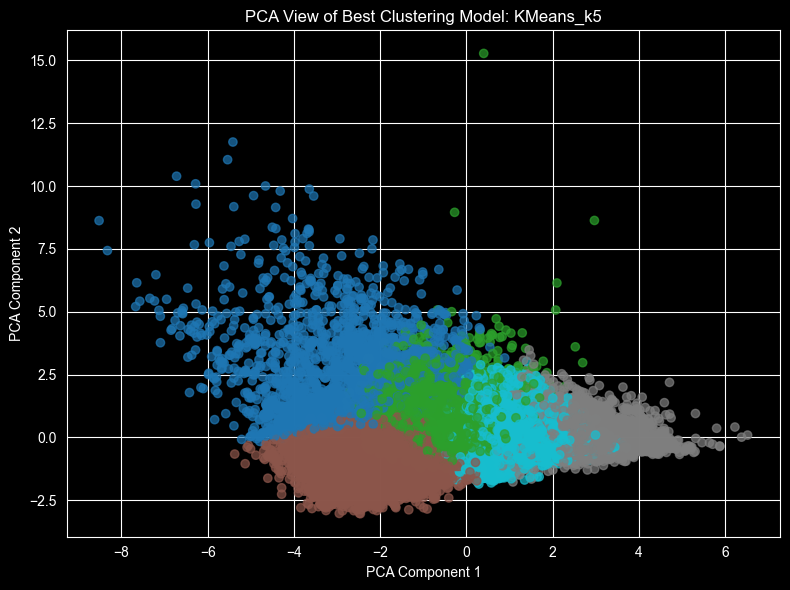

In [51]:
# Plot the result so the pattern is easier to interpret visually.
plt.figure(figsize=(8, 6))
# Filter the data to keep the records relevant for this step.
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap="tab10", alpha=0.7)
plt.title(f"PCA View of Best Clustering Model: {best_model_name}")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.tight_layout()
plt.show()

## Build cluster assignments and similarity outputs

These outputs are designed to make the clusters usable, not just measurable. In addition to cluster labels, the notebook builds representative materials, feature rankings, and nearest-neighbor material comparisons so the clusters can later support pricing and candidate-alternative analysis.

In [52]:
# Group similar records and evaluate the quality of the cluster structure.
cluster_assignments_df = reference_df.copy()
cluster_assignments_df["cluster_label"] = best_labels

cluster_feature_profile_df = features_df.copy()
cluster_feature_profile_df["cluster_label"] = best_labels

# Summarise the data so patterns can be compared more easily.
cluster_summary_df = cluster_feature_profile_df.groupby("cluster_label").mean(numeric_only=True).reset_index()
cluster_size_df = (
    cluster_assignments_df["cluster_label"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_label")
    .reset_index(name="material_count")
)

# Filter the data to keep the records relevant for this step.
cluster_feature_zscore_df = cluster_feature_profile_df.groupby("cluster_label")[feature_names].mean()
cluster_feature_zscore_df = (
    cluster_feature_zscore_df - cluster_feature_zscore_df.mean(axis=0)
) / cluster_feature_zscore_df.std(axis=0).replace(0, np.nan)
# Handle missing values so later transformations and models do not fail.
cluster_feature_zscore_df = cluster_feature_zscore_df.fillna(0)

distance_rows = []
for cluster_label in sorted(pd.unique(best_labels)):
    cluster_mask = best_labels == cluster_label
    cluster_indices = np.where(cluster_mask)[0]
    cluster_points = X_scaled[cluster_mask]
    cluster_center = cluster_points.mean(axis=0)
    distances = np.linalg.norm(cluster_points - cluster_center, axis=1)

    for material_index, distance in zip(cluster_indices, distances):
        distance_rows.append(
            {
                "row_index": int(material_index),
                "cluster_label": int(cluster_label),
                "distance_to_cluster_center": float(distance),
            }
        )

cluster_distance_df = pd.DataFrame(distance_rows)
cluster_representatives_df = (
    cluster_assignments_df.reset_index(names="row_index")
    .merge(cluster_distance_df, on=["row_index", "cluster_label"], how="left")
    .sort_values(["cluster_label", "distance_to_cluster_center"])
    .groupby("cluster_label", as_index=False)
    .head(5)
    .reset_index(drop=True)
)

feature_ranking_rows = []
for cluster_label in cluster_feature_zscore_df.index:
    feature_profile = cluster_feature_zscore_df.loc[cluster_label]
    ranked_features = feature_profile.abs().sort_values(ascending=False).head(3).index.tolist()
    for rank_position, feature_name in enumerate(ranked_features, start=1):
        feature_ranking_rows.append(
            {
                "cluster_label": int(cluster_label),
                "rank_position": rank_position,
                "feature_name": feature_name,
                "feature_zscore": float(feature_profile[feature_name]),
            }
        )

cluster_feature_rank_df = pd.DataFrame(feature_ranking_rows)

neighbor_rows = []
neighbors_per_material = 5
for cluster_label in sorted(pd.unique(best_labels)):
    cluster_mask = best_labels == cluster_label
    cluster_indices = np.where(cluster_mask)[0]
    cluster_points = X_scaled[cluster_mask]

    if len(cluster_indices) < 2:
        continue

    neighbor_count = min(neighbors_per_material + 1, len(cluster_indices))
    # Define the model or model set that will be trained and compared.
    nn_model = NearestNeighbors(n_neighbors=neighbor_count, metric="euclidean")
    # Train the model or transformer on the prepared data.
    nn_model.fit(cluster_points)
    distances, indices = nn_model.kneighbors(cluster_points)

    for local_row_index, material_index in enumerate(cluster_indices):
        source_material = reference_df.iloc[material_index]
        for distance_value, neighbor_local_index in zip(distances[local_row_index][1:], indices[local_row_index][1:]):
            neighbor_index = cluster_indices[neighbor_local_index]
            neighbor_material = reference_df.iloc[neighbor_index]
            neighbor_rows.append(
                {
                    "cluster_label": int(cluster_label),
                    "source_row_index": int(material_index),
                    "source_material_id": source_material.get("material_id"),
                    "source_formula_pretty": source_material.get("formula_pretty"),
                    "neighbor_row_index": int(neighbor_index),
                    "neighbor_material_id": neighbor_material.get("material_id"),
                    "neighbor_formula_pretty": neighbor_material.get("formula_pretty"),
                    "similarity_distance": float(distance_value),
                }
            )

cluster_neighbors_df = pd.DataFrame(neighbor_rows)
cluster_neighbors_preview_df = (
    cluster_neighbors_df.sort_values(["cluster_label", "source_formula_pretty", "similarity_distance"])
    .groupby(["cluster_label", "source_formula_pretty"], as_index=False)
    .head(3)
    .reset_index(drop=True)
)

# Inspect the data to confirm the structure and values look reasonable.
display(cluster_assignments_df.head())
display(cluster_size_df)
display(cluster_summary_df)
display(cluster_representatives_df)
display(cluster_feature_rank_df)
display(cluster_neighbors_preview_df)

,material_id,formula_pretty,formula_match_key,elements,elements_list,material_family_key,material_family_match_key,is_stable,is_metal,symmetry,cluster_label
0,mp-862690,Ac,ac,['Ac'],['Ac'],Ac,ac,True,True,Hexagonal,3
1,mp-1183076,Ac2AgPb,ac2agpb,"['Ac', 'Ag', 'Pb']","['Ac', 'Ag', 'Pb']",Ac_Ag_Pb,ac_ag_pb,True,True,Cubic,3
2,mp-1183086,Ac2CdHg,ac2cdhg,"['Ac', 'Cd', 'Hg']","['Ac', 'Cd', 'Hg']",Ac_Cd_Hg,ac_cd_hg,True,True,Cubic,3
3,mp-862786,Ac2CuGe,ac2cuge,"['Ac', 'Cu', 'Ge']","['Ac', 'Cu', 'Ge']",Ac_Cu_Ge,ac_cu_ge,True,True,Cubic,3
4,mp-861883,Ac2CuIr,ac2cuir,"['Ac', 'Cu', 'Ir']","['Ac', 'Cu', 'Ir']",Ac_Cu_Ir,ac_cu_ir,True,True,Cubic,3


,cluster_label,material_count
0,0,2191
1,1,5640
2,2,9594
3,3,3626
4,4,12900


,cluster_label,nelements,nsites,density,density_atomic,volume,band_gap,energy_per_atom,formation_energy_per_atom,is_metal_flag
0,0,3.656321,99.446828,4.218815,20.550109,1925.951254,2.051337,-6.302270,-1.626358,0.146508
1,1,3.063830,21.214362,4.544856,28.786021,607.618975,1.400600,-7.648350,-1.193116,0.068617
2,2,3.753179,33.059308,4.542279,14.481368,467.671350,3.102413,-7.281099,-2.504759,0.021055
3,3,2.519029,9.221456,10.565600,21.424313,195.712051,0.036843,-32.695590,-0.674012,0.943740
4,4,2.897132,14.752868,7.820310,18.092011,257.831999,0.014698,-8.042816,-0.775269,0.973023


,row_index,material_id,formula_pretty,formula_match_key,elements,elements_list,material_family_key,material_family_match_key,is_stable,is_metal,symmetry,cluster_label,distance_to_cluster_center
0,2085,mp-561502,Ba8B5N10F,ba8b5n10f,"['B', 'Ba', 'F', 'N']","['B', 'Ba', 'F', 'N']",B_Ba_F_N,b_ba_f_n,True,False,Triclinic,0,0.649944
1,4266,mp-557926,CdAs2(XeF5)4,cdas2_xef5_4,"['As', 'Cd', 'F', 'Xe']","['As', 'Cd', 'F', 'Xe']",As_Cd_F_Xe,as_cd_f_xe,True,False,Orthorhombic,0,0.865623
2,25156,mp-1205033,Sb3Au(XeF9)2,sb3au_xef9_2,"['Au', 'F', 'Sb', 'Xe']","['Au', 'F', 'Sb', 'Xe']",Au_F_Sb_Xe,au_f_sb_xe,True,False,Monoclinic,0,0.903370
3,2608,mp-554796,BaSc3AgS6,basc3ags6,"['Ag', 'Ba', 'S', 'Sc']","['Ag', 'Ba', 'S', 'Sc']",Ag_Ba_S_Sc,ag_ba_s_sc,True,False,Orthorhombic,0,0.942740
4,17890,mp-555546,MgAs2(XeF5)4,mgas2_xef5_4,"['As', 'F', 'Mg', 'Xe']","['As', 'F', 'Mg', 'Xe']",As_F_Mg_Xe,as_f_mg_xe,True,False,Orthorhombic,0,1.011593
5,2683,mp-27499,BaTeS3,bates3,"['Ba', 'S', 'Te']","['Ba', 'S', 'Te']",Ba_S_Te,ba_s_te,True,False,Orthorhombic,1,0.499455
6,18598,mp-1221539,MoBr3O,mobr3o,"['Br', 'Mo', 'O']","['Br', 'Mo', 'O']",Br_Mo_O,br_mo_o,True,False,Monoclinic,1,0.507462
7,6603,mp-573358,CsBSe3,csbse3,"['B', 'Cs', 'Se']","['B', 'Cs', 'Se']",B_Cs_Se,b_cs_se,True,False,Monoclinic,1,0.563637
8,20709,mp-23498,NbSeBr3,nbsebr3,"['Br', 'Nb', 'Se']","['Br', 'Nb', 'Se']",Br_Nb_Se,br_nb_se,True,False,Monoclinic,1,0.585949
9,2556,mp-11008,BaPSe3,bapse3,"['Ba', 'P', 'Se']","['Ba', 'P', 'Se']",Ba_P_Se,ba_p_se,True,False,Monoclinic,1,0.591043


,cluster_label,rank_position,feature_name,feature_zscore
0,0,1,volume,1.740085
1,0,2,nsites,1.736103
2,0,3,nelements,0.918269
3,1,1,density_atomic,1.538534
4,1,2,is_metal_flag,-0.747884
5,1,3,density,-0.644242
6,2,1,formation_energy_per_atom,-1.543172
7,2,2,band_gap,1.339933
8,2,3,density_atomic,-1.172083
9,3,1,energy_per_atom,-1.785966


,cluster_label,source_row_index,source_material_id,source_formula_pretty,neighbor_row_index,neighbor_material_id,neighbor_formula_pretty,similarity_distance
0,0,80,mp-567334,Ag(BCl)6,16167,mp-532413,Li5B7S13,0.900152
1,0,80,mp-567334,Ag(BCl)6,19679,mp-640950,NaB9Se8,1.085639
2,0,80,mp-567334,Ag(BCl)6,19542,mp-1220895,Na6B18Se17,1.113587
3,0,82,mp-568392,Ag10Te4Br3,13027,mp-569136,K3Cu11Te16,0.815739
4,0,82,mp-568392,Ag10Te4Br3,125,mp-662599,Ag3AsSe3,0.899354
...,...,...,...,...,...,...,...,...
101509,4,33949,mp-1100780,ZrZnPd2,25620,mp-867909,ScCdRh2,0.092681
101510,4,33949,mp-1100780,ZrZnPd2,18090,mp-866073,MgSnRh2,0.110922
101511,4,33950,mp-977582,ZrZnRh2,33704,mp-1068661,ZrBRh3,0.214322
101512,4,33950,mp-977582,ZrZnRh2,30050,mp-865640,TiGeRu2,0.242251


## Interpret the best clustering model

The interpretation step is used to understand what each cluster represents in practice. We inspect cluster size, feature profiles, central materials, and within-cluster similarity so the groups can be described as meaningful material families before cost is introduced.

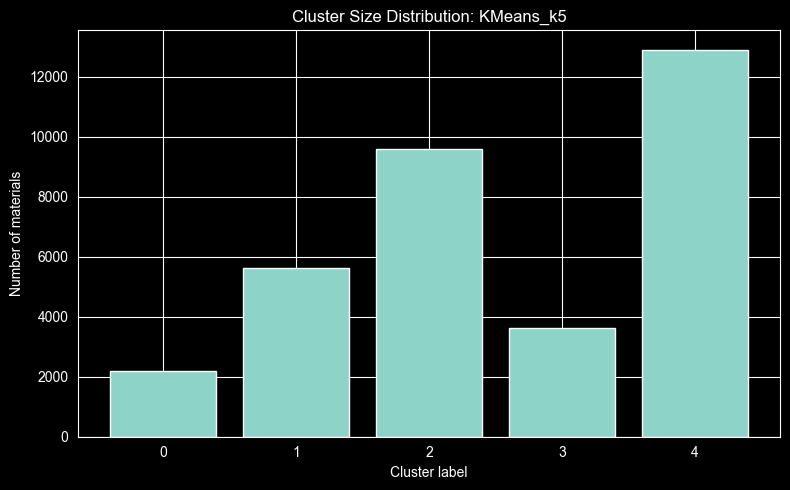

In [53]:
# Plot the result so the pattern is easier to interpret visually.
plt.figure(figsize=(8, 5))
# Convert values into analysis-friendly numeric, date, or text formats.
plt.bar(cluster_size_df["cluster_label"].astype(str), cluster_size_df["material_count"])
plt.title(f"Cluster Size Distribution: {best_model_name}")
plt.xlabel("Cluster label")
plt.ylabel("Number of materials")
plt.tight_layout()
plt.show()

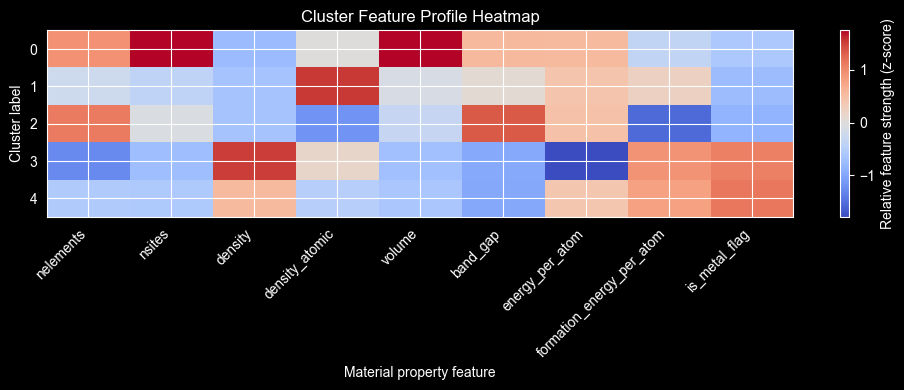

In [54]:
# Group similar records and evaluate the quality of the cluster structure.
heatmap_values = cluster_feature_zscore_df.to_numpy(dtype=float)

# Choose the columns that will be used as features or summary variables.
plt.figure(figsize=(max(10, len(feature_names) * 0.7), max(4, len(cluster_feature_zscore_df) * 0.8)))
image = plt.imshow(heatmap_values, aspect="auto", cmap="coolwarm")
# Plot the result so the pattern is easier to interpret visually.
plt.colorbar(image, label="Relative feature strength (z-score)")
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha="right")
# Convert values into analysis-friendly numeric, date, or text formats.
plt.yticks(range(len(cluster_feature_zscore_df.index)), cluster_feature_zscore_df.index.astype(str))
plt.title("Cluster Feature Profile Heatmap")
plt.xlabel("Material property feature")
plt.ylabel("Cluster label")
plt.tight_layout()
plt.show()

In [55]:
display_columns = [
    column for column in [
        # Group similar records and evaluate the quality of the cluster structure.
        "cluster_label",
        "formula_pretty",
        "material_id",
        "material_family_key",
        "distance_to_cluster_center",
    ]
    if column in cluster_representatives_df.columns
]

# Filter the data to keep the records relevant for this step.
representative_preview_df = cluster_representatives_df[display_columns].copy()
# Inspect the data to confirm the structure and values look reasonable.
display(representative_preview_df)

,cluster_label,formula_pretty,material_id,material_family_key,distance_to_cluster_center
0,0,Ba8B5N10F,mp-561502,B_Ba_F_N,0.649944
1,0,CdAs2(XeF5)4,mp-557926,As_Cd_F_Xe,0.865623
2,0,Sb3Au(XeF9)2,mp-1205033,Au_F_Sb_Xe,0.903370
3,0,BaSc3AgS6,mp-554796,Ag_Ba_S_Sc,0.942740
4,0,MgAs2(XeF5)4,mp-555546,As_F_Mg_Xe,1.011593
5,1,BaTeS3,mp-27499,Ba_S_Te,0.499455
6,1,MoBr3O,mp-1221539,Br_Mo_O,0.507462
7,1,CsBSe3,mp-573358,B_Cs_Se,0.563637
8,1,NbSeBr3,mp-23498,Br_Nb_Se,0.585949
9,1,BaPSe3,mp-11008,Ba_P_Se,0.591043


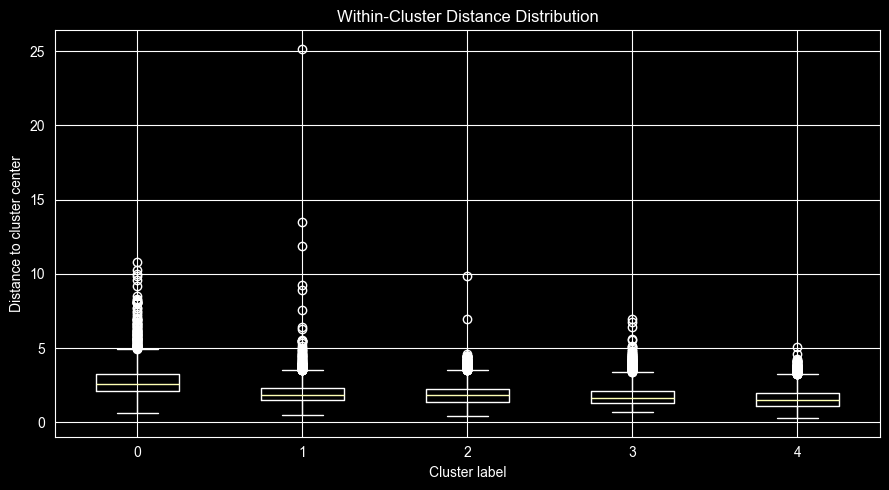

In [56]:
# Filter the data to keep the records relevant for this step.
distance_boxplot_data = []
distance_boxplot_labels = []
# Group similar records and evaluate the quality of the cluster structure.
for cluster_label in sorted(cluster_distance_df["cluster_label"].unique()):
    values = cluster_distance_df.loc[
        cluster_distance_df["cluster_label"] == cluster_label,
        "distance_to_cluster_center",
    ].to_numpy()
    if len(values) > 0:
        distance_boxplot_data.append(values)
        distance_boxplot_labels.append(str(cluster_label))

# Plot the result so the pattern is easier to interpret visually.
plt.figure(figsize=(9, 5))
plt.boxplot(distance_boxplot_data, tick_labels=distance_boxplot_labels)
plt.title("Within-Cluster Distance Distribution")
plt.xlabel("Cluster label")
plt.ylabel("Distance to cluster center")
plt.tight_layout()
plt.show()

In [57]:
# Summarise the data so patterns can be compared more easily.
cluster_feature_rank_pivot_df = cluster_feature_rank_df.pivot(
    # Group similar records and evaluate the quality of the cluster structure.
    index="cluster_label",
    columns="rank_position",
    values="feature_name",
).rename(columns={1: "top_feature_1", 2: "top_feature_2", 3: "top_feature_3"})

# Inspect the data to confirm the structure and values look reasonable.
display(cluster_feature_rank_pivot_df.reset_index())
display(cluster_neighbors_preview_df.head(20))

rank_position,cluster_label,top_feature_1,top_feature_2,top_feature_3
0,0,volume,nsites,nelements
1,1,density_atomic,is_metal_flag,density
2,2,formation_energy_per_atom,band_gap,density_atomic
3,3,energy_per_atom,density,nelements
4,4,is_metal_flag,band_gap,formation_energy_per_atom


,cluster_label,source_row_index,source_material_id,source_formula_pretty,neighbor_row_index,neighbor_material_id,neighbor_formula_pretty,similarity_distance
0,0,80,mp-567334,Ag(BCl)6,16167,mp-532413,Li5B7S13,0.900152
1,0,80,mp-567334,Ag(BCl)6,19679,mp-640950,NaB9Se8,1.085639
2,0,80,mp-567334,Ag(BCl)6,19542,mp-1220895,Na6B18Se17,1.113587
3,0,82,mp-568392,Ag10Te4Br3,13027,mp-569136,K3Cu11Te16,0.815739
4,0,82,mp-568392,Ag10Te4Br3,125,mp-662599,Ag3AsSe3,0.899354
5,0,82,mp-568392,Ag10Te4Br3,30398,mp-30236,TlAsSe2,0.956638
6,0,83,mp-1195193,Ag12Sn7H16(Se11N2)2,21888,mp-1196394,P2H19C6I7N,1.342787
7,0,83,mp-1195193,Ag12Sn7H16(Se11N2)2,30379,mp-581586,Tl8Sb21As19(PbS17)4,1.344317
8,0,83,mp-1195193,Ag12Sn7H16(Se11N2)2,24268,mp-1195451,Rb6U3Sb2(PS4)8,1.627885
9,0,84,mp-560328,Ag15P4S16Cl3,25825,mp-650178,Se5SO3F,0.695101


## Save clustering outputs

The saved files are split into core downstream outputs and supporting analysis outputs. The core files are meant for the next cost-integration stage, while the supporting files preserve the evaluation evidence for reporting and appendix use.

In [58]:
# Group similar records and evaluate the quality of the cluster structure.
cluster_metrics_df.to_csv(cluster_metrics_output, index=False)
# Save the processed output so later notebooks or report sections can reuse it.
cluster_assignments_df.to_csv(cluster_assignments_output, index=False)
cluster_summary_df.to_csv(cluster_summary_output, index=False)
cluster_representatives_df.to_csv(cluster_representatives_output, index=False)
cluster_neighbors_df.to_csv(cluster_neighbors_output, index=False)
cluster_feature_rank_df.to_csv(cluster_feature_rank_output, index=False)

print(f"Saved cluster assignments to: {cluster_assignments_output}")
print(f"Saved cluster nearest neighbors to: {cluster_neighbors_output}")
print(f"Saved cluster feature rankings to: {cluster_feature_rank_output}")
# Calculate evaluation metrics to judge model or pipeline performance.
print(f"Saved supporting model comparison to: {cluster_metrics_output}")
print(f"Saved supporting cluster summary to: {cluster_summary_output}")
print(f"Saved supporting cluster representatives to: {cluster_representatives_output}")

Saved cluster assignments to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_clustering\materials_cluster_assignments.csv
Saved cluster nearest neighbors to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_clustering\materials_cluster_nearest_neighbors.csv
Saved cluster feature rankings to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_clustering\materials_cluster_feature_rankings.csv
Saved supporting model comparison to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_clustering\supporting\materials_cluster_model_comparison.csv
Saved supporting cluster summary to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Data analytics for Artificial intelligence\Project\results\materials_clustering\supporting\mater